deposit: total_deposit
withdraw: withdrawal_requested
wager: total_wagered
loss: net_loss
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8304
           1       0.88      0.91      0.89      2400
           2       0.87      0.75      0.81      1296

    accuracy                           0.95     12000
   macro avg       0.91      0.89      0.90     12000
weighted avg       0.95      0.95      0.95     12000

ROC-AUC: 0.9907892433247215


/home/oem/mlenv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


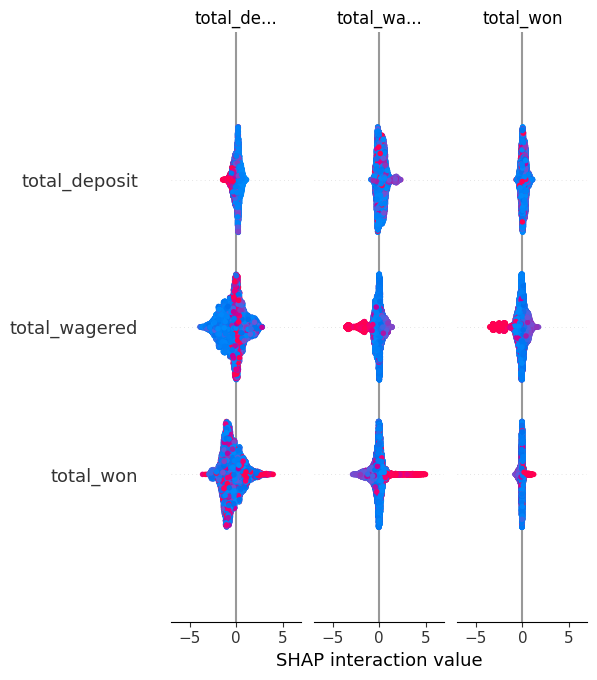

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("synthetic_igaming_risk_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

# helper function to find column containing text
def find_col(keyword):
    for c in df.columns:
        if keyword in c.lower():
            return c
    return None

deposit_col = find_col("deposit")
withdraw_col = find_col("withdraw")
wager_col = find_col("wager")
loss_col = find_col("loss")

print("deposit:", deposit_col)
print("withdraw:", withdraw_col)
print("wager:", wager_col)
print("loss:", loss_col)

df["deposit_to_wager_ratio"] = df[wager_col] / (df[deposit_col] + 1)

df["loss_ratio"] = df[loss_col] / (df[wager_col] + 1)

df["failed_deposit_ratio"] = df["failed_deposits"] / (df[deposit_col] + 1)

df["withdrawal_ratio"] = df[withdraw_col] / (df[wager_col] + 1)

df["night_binge_flag"] = (df["night_play_ratio"] > 0.6).astype(int)

df["long_session_flag"] = (df["session_duration_minutes"] > 180).astype(int)

drop_cols = [
    "player_id",
    "date",
    "archetype",
]

X = df.drop(columns=drop_cols + ["risk_label"])
y = df["risk_label"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print(classification_report(y_test, y_pred))

roc = roc_auc_score(
    y_test,
    y_prob,
    multi_class="ovr"
)

print("ROC-AUC:", roc)

import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)